In [1]:
data_dir = '/scratch/mjehangir/manuscript_figures/manuscript_data/'

In [2]:
setwd(data_dir)

In [3]:
# Load necessary libraries
library(openxlsx)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ComplexHeatmap)
library(circlize)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: grid

ComplexHeatmap version 2.22.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


circlize version 0.4.16
CRAN page: https://cran.r-project.org/package

In [4]:
# Read the CSV file into a data frame
df_cnv <- read.delim("Mean_normalized_v3_tab.seg", header = TRUE)
df_arms <- read.delim("chm13_p_q_arm_length.tsv", header = TRUE)

# Set column names
#colnames(df) <- c("Sample", "Chromosome", "Value", "Other_1", "Arm")

# View the data
head(df_cnv)
head(df_arms)
nrow(df_cnv)

,ID,chrom,loc.start,loc.end,num.mark,seg.mean,Arm
,<chr>,<int>,<int>,<int>,<int>,<dbl>,<lgl>
1,2436A,1,200151,28021140,130,0.0534,NA
2,2436A,1,142707663,142907814,2,1.3533,NA
3,2436A,10,88303635,101719380,68,0.0066,NA
4,2436A,10,101919615,104722905,15,-0.1040,NA
5,2436A,10,104923140,112932540,41,-0.0198,NA
6,2436A,10,113132775,120741705,39,-0.4022,NA


,Chromosome,Start,End,Length,Arm
,<chr>,<int>,<int>,<int>,<chr>
1,chr1,0,124048267,124048267,p
2,chr1,124048267,248387328,124339061,q
3,chr10,0,40649191,40649191,p
4,chr10,40649191,134758134,94108943,q
5,chr11,0,52743313,52743313,p
6,chr11,52743313,135127769,82384456,q


[1] 2019

In [5]:
df_cnv <- df_cnv %>% mutate(chrom = paste0("chr", chrom))
head(df_cnv)

,ID,chrom,loc.start,loc.end,num.mark,seg.mean,Arm
,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<lgl>
1,2436A,chr1,200151,28021140,130,0.0534,NA
2,2436A,chr1,142707663,142907814,2,1.3533,NA
3,2436A,chr10,88303635,101719380,68,0.0066,NA
4,2436A,chr10,101919615,104722905,15,-0.1040,NA
5,2436A,chr10,104923140,112932540,41,-0.0198,NA
6,2436A,chr10,113132775,120741705,39,-0.4022,NA


In [6]:
df_cnv <- df_cnv %>%
  filter(num.mark > 0)
nrow(df_cnv)

[1] 2019

In [7]:
# Merge the data frames to assign p/q arm based on start and end positions
df_cnv_with_arms <- df_cnv %>%
  left_join(df_arms, by = c("chrom" = "Chromosome")) %>%
  filter(loc.start >= Start & loc.end <= End) %>%
  select(ID, chrom, loc.start, loc.end, num.mark, seg.mean)

# View the resulting data frame with arm assignments
head(df_cnv_with_arms)

Warning message in left_join(., df_arms, by = c(chrom = "Chromosome")):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1 of `x` matches multiple rows in `y`.
ℹ Row 1 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”


,ID,chrom,loc.start,loc.end,num.mark,seg.mean
,<chr>,<chr>,<int>,<int>,<int>,<dbl>
1,2436A,chr1,200151,28021140,130,0.0534
2,2436A,chr1,142707663,142907814,2,1.3533
3,2436A,chr10,88303635,101719380,68,0.0066
4,2436A,chr10,101919615,104722905,15,-0.1040
5,2436A,chr10,104923140,112932540,41,-0.0198
6,2436A,chr10,113132775,120741705,39,-0.4022


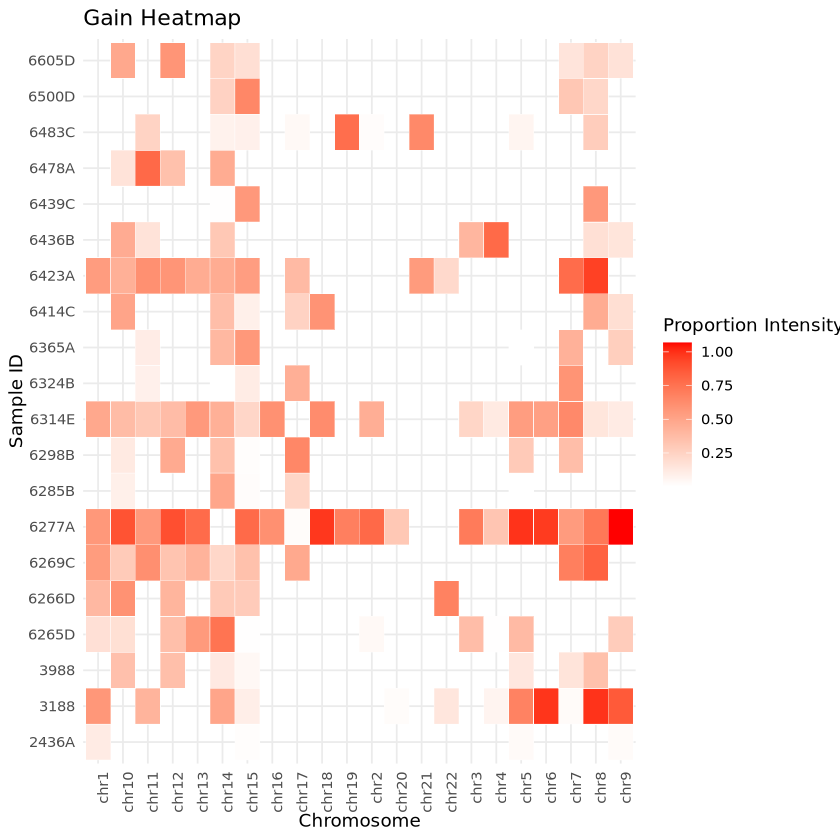

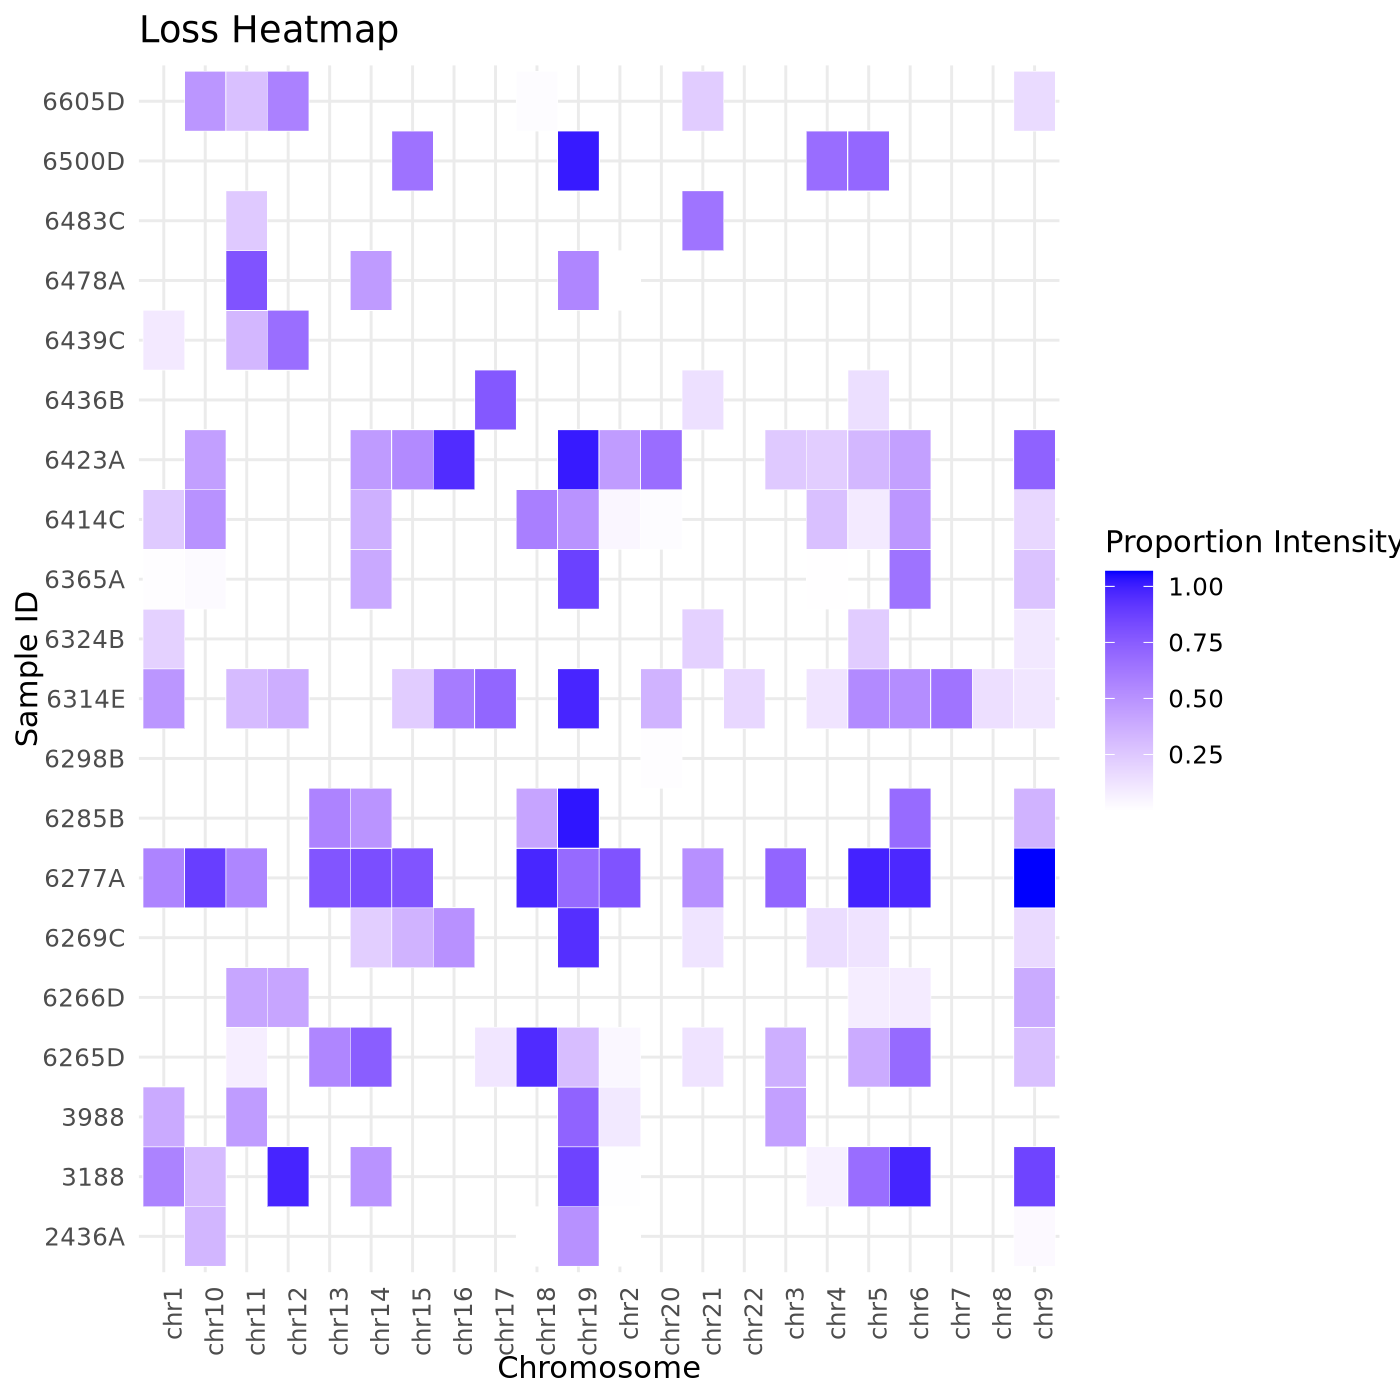

In [8]:
# Step 1: Count CNVs per chromosome per sample
cnv_counts <- df_cnv %>%
  group_by(ID, chrom) %>%
  summarise(CNV_Count = n(), .groups = "drop")

# Step 2: Calculate proportion of affected chromosome length
chromosome_lengths <- tibble(
  chrom = c("chr1", "chr2", "chr3", "chr4", "chr5", "chr6", "chr7", "chr8", "chr9", "chr10",
            "chr11", "chr12", "chr13", "chr14", "chr15", "chr16", "chr17", "chr18", "chr19", "chr20",
            "chr21", "chr22", "chrX", "chrY"),
  Length = c(248956422, 242193529, 198295559, 190214555, 181538259, 170805979, 159345973, 145138636,
             138394717, 133797422, 135086622, 133275309, 114364328, 107043718, 101991189, 90338345,
             83257441, 80373285, 58617616, 64444167, 46709983, 50818468, 156040895, 57227415)
)

cnv_proportions <- df_cnv %>%
  left_join(chromosome_lengths, by = "chrom") %>%
  mutate(Affected_Length = loc.end - loc.start) %>%
  group_by(ID, chrom) %>%
  summarise(
    Total_Affected = sum(Affected_Length, na.rm = TRUE),
    Chrom_Length = unique(Length),
    Proportion_Affected = Total_Affected / Chrom_Length,
    .groups = "drop"
  )

# Step 3: Assign Gain, Loss, or Neutral based on seg.mean
df_cnv$Gain_Loss <- case_when(
  df_cnv$seg.mean < -0.2 ~ "Loss",
  df_cnv$seg.mean > 0.2 ~ "Gain",
  TRUE ~ "Neutral"
)

# Step 4: Merge counts & proportions
final_data <- cnv_counts %>%
  left_join(cnv_proportions, by = c("ID", "chrom")) %>%
  left_join(df_cnv %>% select(ID, chrom, Gain_Loss), by = c("ID", "chrom"))

# Step 5: Create separate heatmaps for Gain and Loss

# Gain heatmap (red)
final_data_gain <- final_data %>%
  filter(Gain_Loss == "Gain")

ggplot(final_data_gain, aes(x = chrom, y = ID)) +
  geom_tile(aes(fill = Proportion_Affected), color = "white") + # Tile color for proportion
  scale_fill_gradient(low = "white", high = "red", name = "Proportion Intensity") + # Red for Gain
  #geom_point(aes(size = CNV_Count), color = "black", alpha = 0.4) + # Black dots for CNV counts
  #scale_size(range = c(1, 10), name = "CNV Count") + 
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1),
    legend.position = "right"
  ) +
  labs(title = "Gain Heatmap", x = "Chromosome", y = "Sample ID")

# Loss heatmap (blue)
final_data_loss <- final_data %>%
  filter(Gain_Loss == "Loss")

ggplot(final_data_loss, aes(x = chrom, y = ID)) +
  geom_tile(aes(fill = Proportion_Affected), color = "white") + # Tile color for proportion
  scale_fill_gradient(low = "white", high = "blue", name = "Proportion Intensity") + # Blue for Loss
  #geom_point(aes(size = CNV_Count), color = "black", alpha = 0.5) + # Black dots for CNV counts
  #scale_size(range = c(1, 10), name = "CNV Count") + 
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1),
    legend.position = "right"
  ) +
  labs(title = "Loss Heatmap", x = "Chromosome", y = "Sample ID")
options(repr.plot.width = 5, repr.plot.height = 3, repr.plot.res = 200)


In [9]:
head(final_data)

ID,chrom,CNV_Count,Total_Affected,Chrom_Length,Proportion_Affected,Gain_Loss
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<chr>
2436A,chr1,2,28021140,248956422,0.1125544,Neutral
2436A,chr1,2,28021140,248956422,0.1125544,Gain
2436A,chr10,7,44852621,133797422,0.3352278,Neutral
2436A,chr10,7,44852621,133797422,0.3352278,Neutral
2436A,chr10,7,44852621,133797422,0.3352278,Neutral
2436A,chr10,7,44852621,133797422,0.3352278,Loss


In [33]:
data_dir = '/scratch/mjehangir/manuscript_figures/manuscript_data//plots_f1'

In [15]:
library(dplyr)
library(ggplot2)

# Count CNVs per chromosome (excluding Neutral)
cnv_counts_per_chr <- df_cnv %>%
  filter(Gain_Loss != "Neutral") %>%
  count(chrom, Gain_Loss, name = "count")

# Sort chromosomes (chr1–chr22, chrX, chrY)
cnv_counts_per_chr$chrom <- factor(cnv_counts_per_chr$chrom,
                                   levels = paste0("chr", c(1:22, "X", "Y")))

# Plot
plot_cnv1 <- ggplot(cnv_counts_per_chr, aes(x = chrom, y = count, fill = Gain_Loss)) +
  geom_bar(stat = "identity") +
  theme_classic() +
  labs(title = "CNV Gains and Losses per Chromosome", 
       x = "Chromosome", y = "Count") +
  scale_fill_manual(values = c("Loss" = "blue", "Gain" = "red")) +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))


In [12]:
ggsave("CNV_per_chromosome.pdf",
       plot = plot_cnv1 ,
       width = 7, height = 5, units = "in", useDingbats = FALSE)


In [39]:
head(df_cnv)

,ID,chrom,loc.start,loc.end,num.mark,seg.mean,Arm,Gain_Loss
,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<lgl>,<chr>
1,2436A,chr1,200151,28021140,130,0.0534,NA,Neutral
2,2436A,chr1,142707663,142907814,2,1.3533,NA,Gain
3,2436A,chr10,88303635,101719380,68,0.0066,NA,Neutral
4,2436A,chr10,101919615,104722905,15,-0.1040,NA,Neutral
5,2436A,chr10,104923140,112932540,41,-0.0198,NA,Neutral
6,2436A,chr10,113132775,120741705,39,-0.4022,NA,Loss


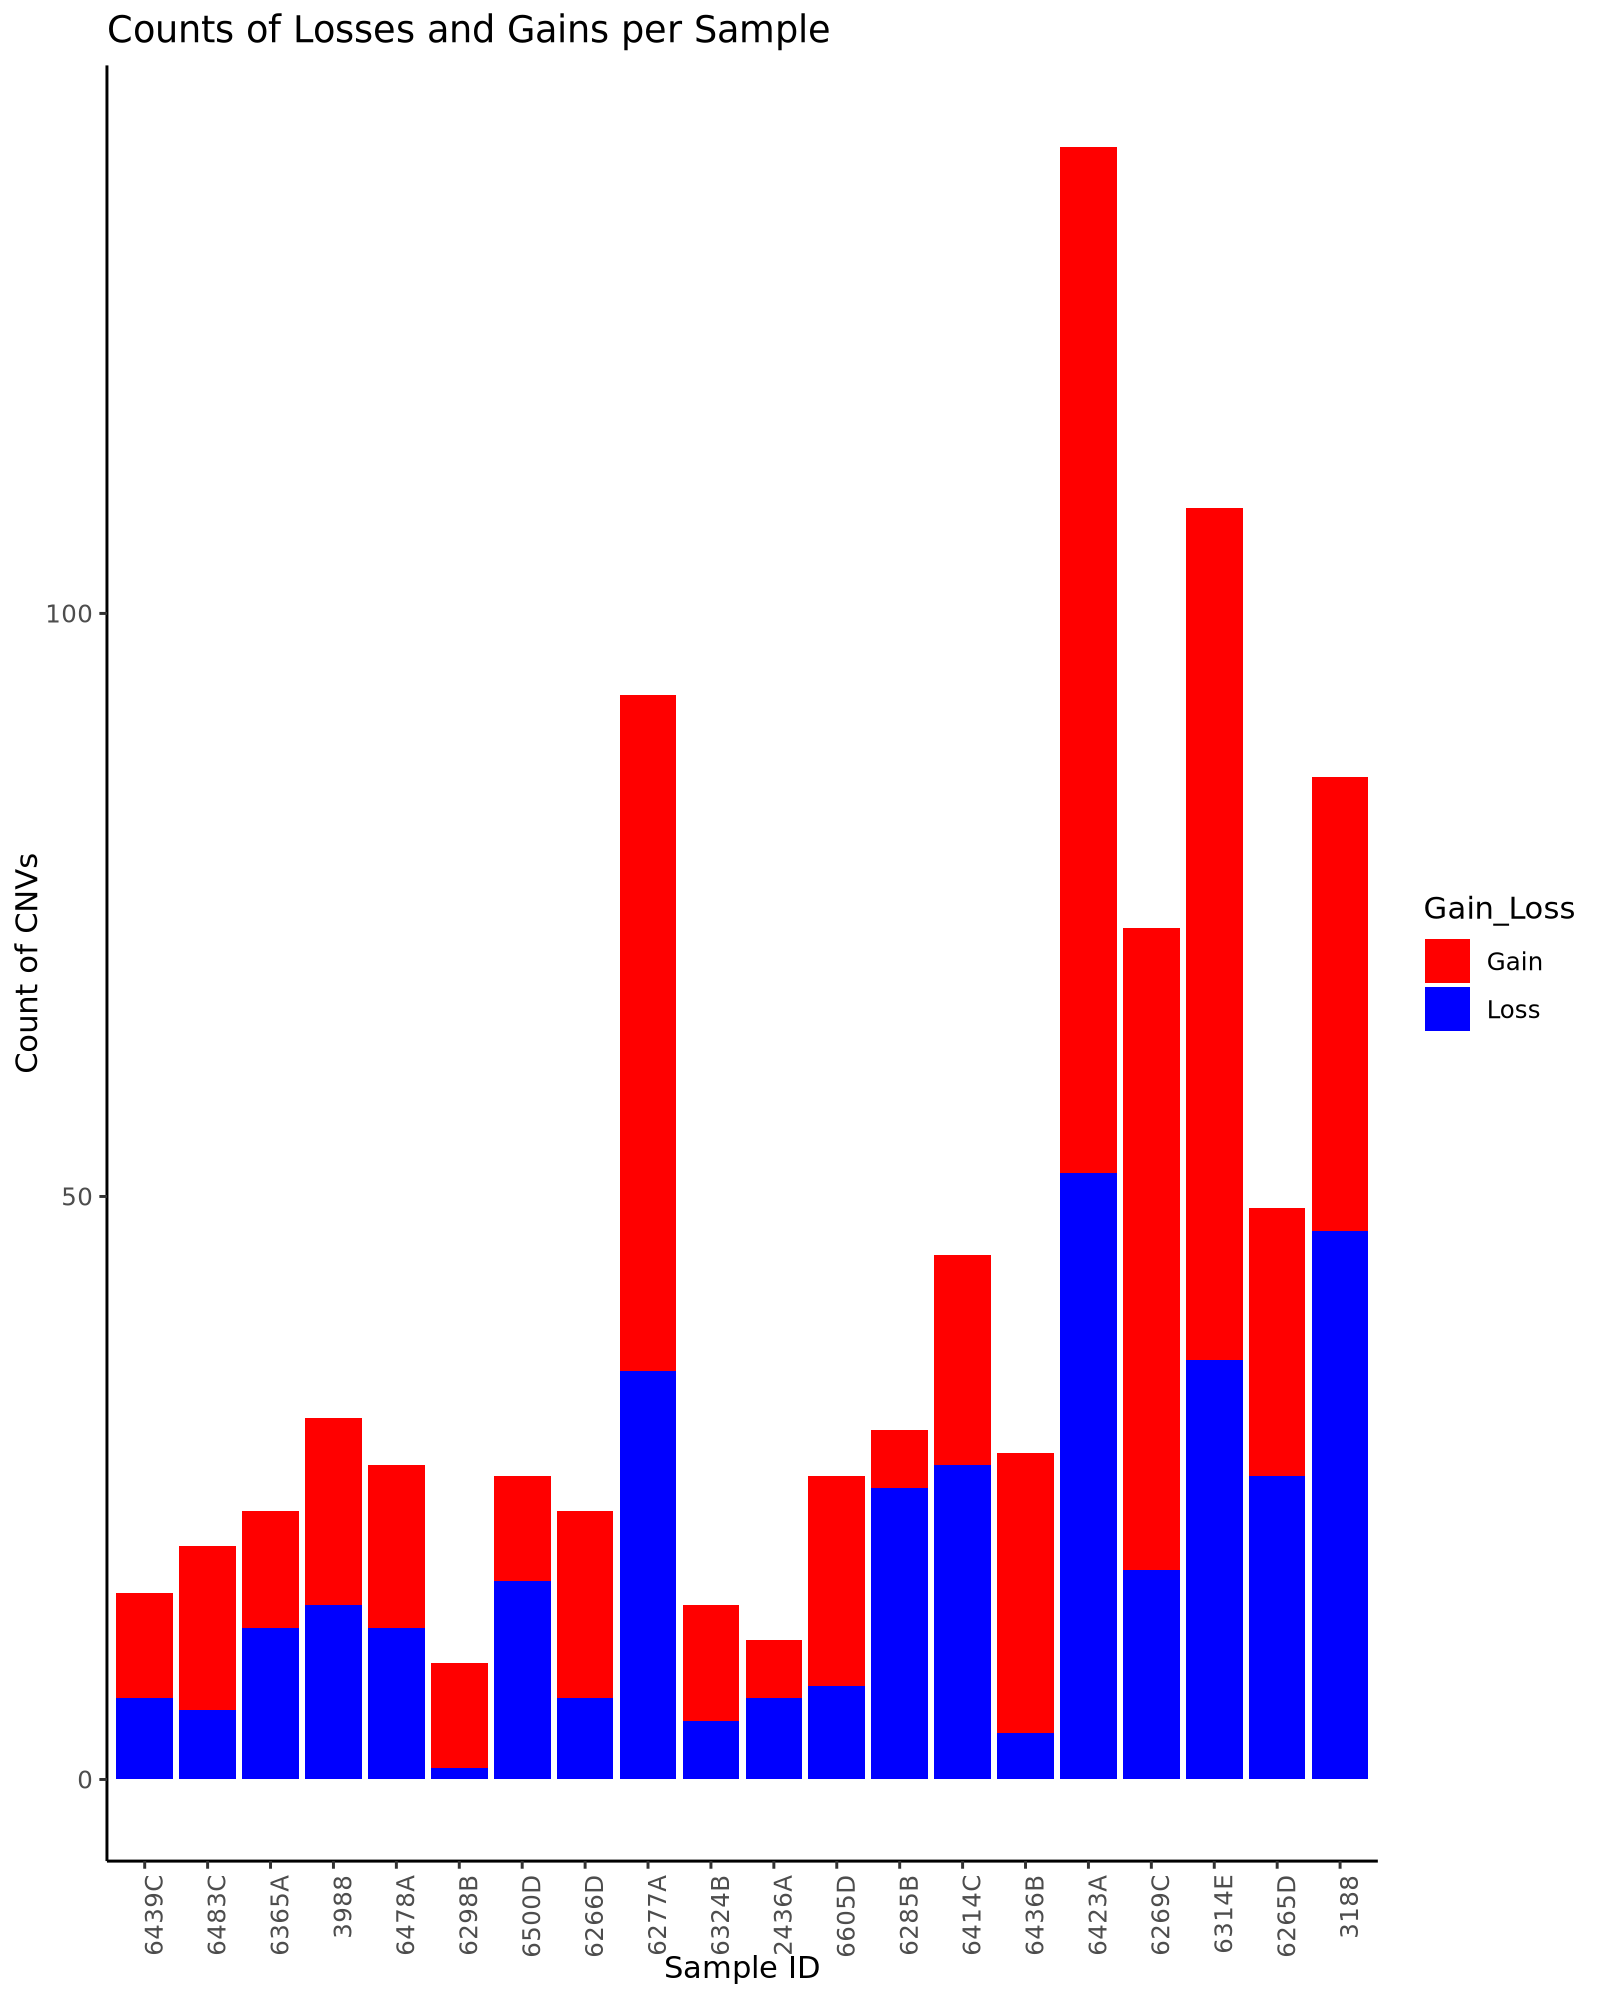

In [40]:


# Step 1: Filter out Neutral CNVs and count Losses and Gains per Sample
cnv_counts_per_sample <- df_cnv %>%
  filter(Gain_Loss != "Neutral") %>%
  group_by(ID, Gain_Loss) %>%
  summarise(count = n(), .groups = "drop")

# Step 2: Define your custom ID order from SV totals
ids <- c("6439C", "6483C", "6365A", "3988", "6478A", "6298B", "6500D", "6266D", 
         "6277A", "6324B", "2436A", "6605D", "6285B", "6414C", "6436B", 
         "6423A", "6269C", "6314E", "6265D", "3188")

# Step 3: Reorder ID factor levels in your CNV summary
cnv_counts_per_sample$ID <- factor(cnv_counts_per_sample$ID, levels = ids)

# Step 4: Plot with custom order preserved
plot_cnv2 <- ggplot(cnv_counts_per_sample, aes(x = ID, y = count, fill = Gain_Loss)) +
  geom_bar(stat = "identity", position = "stack") +
  theme_classic() +
  labs(title = "Counts of Losses and Gains per Sample", x = "Sample ID", y = "Count of CNVs") +
  scale_fill_manual(values = c("Loss" = "blue", "Gain" = "red")) +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))

# Print the plot
print(plot_cnv2)


In [41]:
ggsave("CNV_per_sample.pdf",
       plot = plot_cnv2 ,
       width = 7, height = 5, units = "in", useDingbats = FALSE)

Warning message:
“Groups with fewer than two datapoints have been dropped.
ℹ Set `drop = FALSE` to consider such groups for position adjustment purposes.”


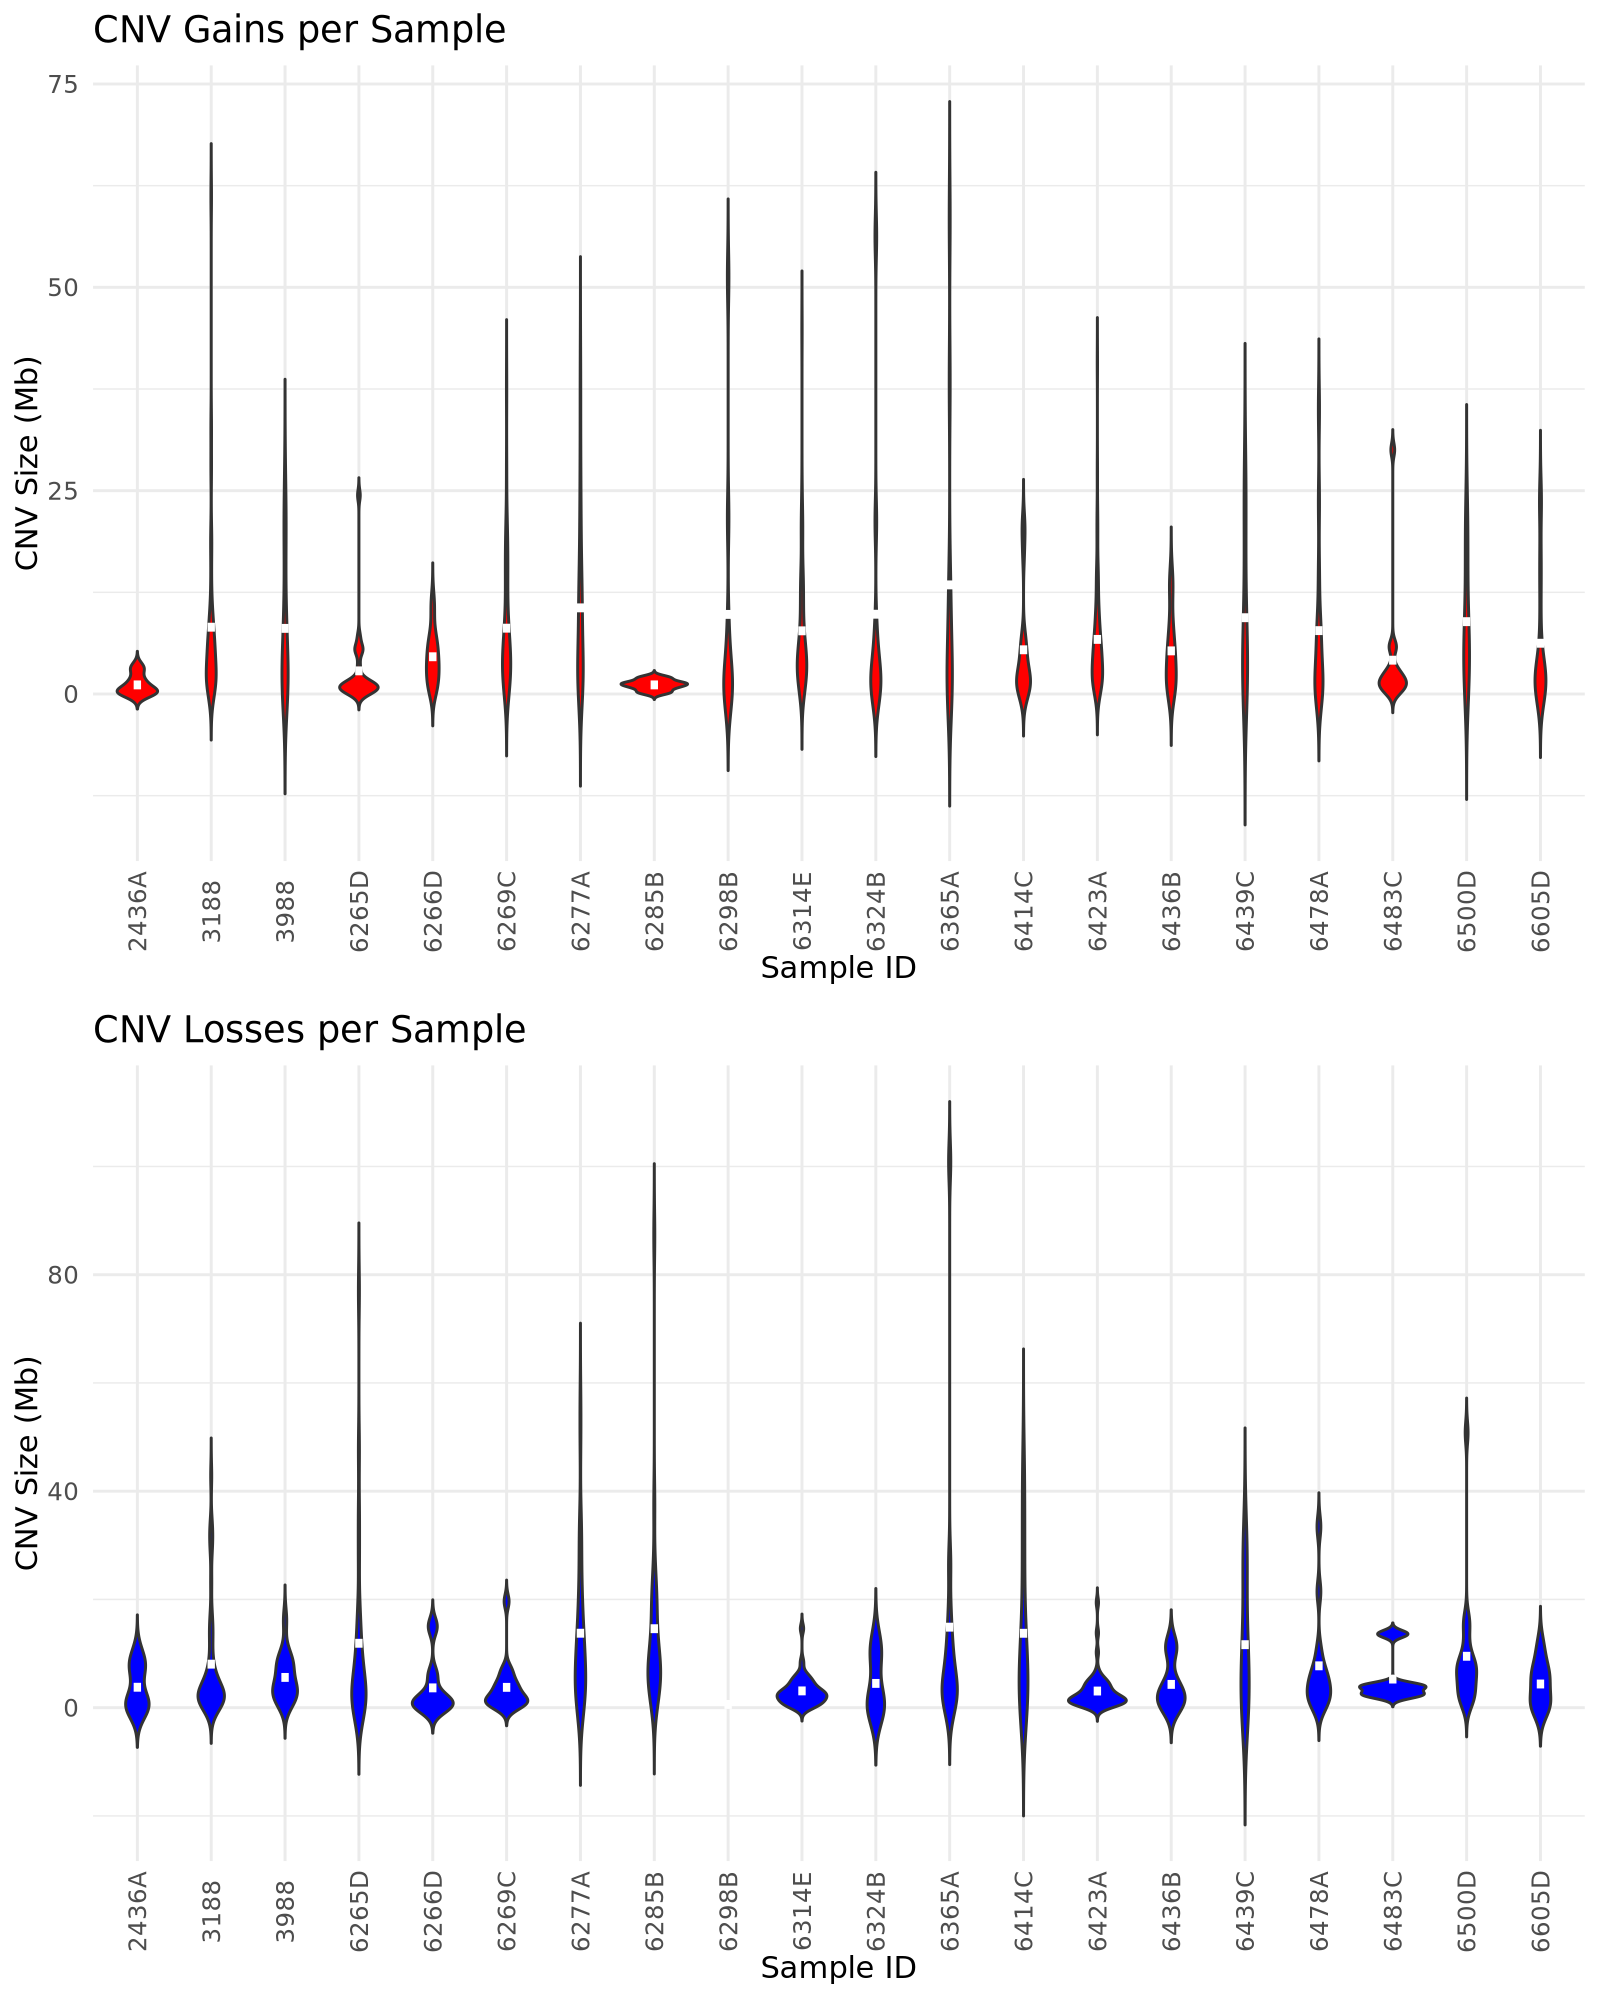

In [26]:
library(ggplot2)
library(dplyr)

# Read your data

# Calculate CNV size and classify as Gain or Loss
df_cnv_with_arms <- df_cnv_with_arms %>%
  mutate(
    size = loc.end - loc.start,
    cnv_type = case_when(
      seg.mean > 0.2 ~ "Gain",
      seg.mean < -0.2 ~ "Loss",
      TRUE ~ NA_character_
    )
  ) %>%
  filter(!is.na(cnv_type))  # Keep only Gain or Loss

# Convert size to megabases (Mb)
df_cnv_with_arms$size_mb <- df_cnv_with_arms$size / 1e6

# Split data
df_gain <- filter(df_cnv_with_arms, cnv_type == "Gain")
df_loss <- filter(df_cnv_with_arms, cnv_type == "Loss")

options(repr.plot.width = 8, repr.plot.height = 10, repr.plot.res = 200)

# 🔴 CNV Gains Violin Plot with White Mean Bar
plot_gain <- ggplot(df_gain, aes(x = ID, y = size_mb)) +
  geom_violin(fill = "red", trim = FALSE) +
  stat_summary(
    fun = mean,
    geom = "crossbar",
    width = 0.1,
    color = "white",
    fatten = 3
  ) +
  theme_minimal() +
  labs(title = "CNV Gains per Sample", x = "Sample ID", y = "CNV Size (Mb)") +
  theme(axis.text.x = element_text(angle = 90, vjust = 0.5))

# 🔵 CNV Losses Violin Plot with White Mean Bar
plot_loss <- ggplot(df_loss, aes(x = ID, y = size_mb)) +
  geom_violin(fill = "blue", trim = FALSE) +
  stat_summary(
    fun = mean,
    geom = "crossbar",
    width = 0.1,
    color = "white",
    fatten = 3
  ) +
  theme_minimal() +
  labs(title = "CNV Losses per Sample", x = "Sample ID", y = "CNV Size (Mb)") +
  theme(axis.text.x = element_text(angle = 90, vjust = 0.5))

# Display both plots vertically
grid.arrange(plot_gain, plot_loss, ncol = 1)


In [38]:
# Your histogram plot (reuse the variable or create it here)
pdf("/scratch/mjehangir/manuscript_figures/manuscript_data/plots_f1/CNV_size_histogram.pdf", width = 8, height = 6)

plot_histogram <- ggplot(df_cnv_with_arms, aes(x = size_mb, fill = cnv_type)) +
  geom_histogram(position = "identity", bins = 50, alpha = 0.5, color = "black") +
  scale_fill_manual(values = c("Gain" = "red", "Loss" = "blue")) +
  theme_minimal(base_size = 14) +
  labs(
    title = "Histogram of CNV Sizes",
    x = "CNV Size (Mb)",
    y = "Count",
    fill = "CNV Type"
  ) +
  theme(
    axis.text.x = element_text(size = 12),
    axis.text.y = element_text(size = 12),
    axis.title = element_text(size = 14),
    legend.title = element_text(size = 14),
    legend.text = element_text(size = 12),
    plot.title = element_text(size = 16, face = "bold")
  )

dev.off()

pdf 
  2